# FIRE m12i — solar-neighborhood bubble exploration

Goals for this notebook:
1. Load the z=0 snapshot with host + disk orientation
2. Work in **principal-axis cylindrical** coordinates `(R, φ, Z)`
3. Visualize the stellar disk
4. Define a ~4 kpc bubble centered at R ≈ 8.2 kpc (Sun-like location)
5. Sample query positions inside that bubble
6. Sketch ways to estimate **gravitational accelerations** at those points

Simulation path: `data/fire` (FIRE-2 m12i_res7100).

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import gizmo_analysis as gizmo
import utilities as ut

%matplotlib inline

SIM_DIR = Path('/Users/pablom.perez/Desktop/Linas-group/data/fire')

# Bubble geometry (galactocentric, principal-axis frame)
R_SUN_KPC = 8.2
BUBBLE_RADIUS_KPC = 4.0

RNG = np.random.default_rng(0)

## 1. Load snapshot

Read stars + high-res dark matter at z=0.
`assign_hosts_rotation=True` puts us in the stellar-disk principal-axis frame
(via `track/host_coordinates.hdf5`).

We only read the properties we need to keep memory down.

In [2]:
part = gizmo.io.Read.read_snapshots(
    ['star', 'dark'],
    'redshift',
    0,
    str(SIM_DIR),
    properties=['position', 'mass', 'potential', 'velocity'],
    assign_hosts_rotation=True,
)

print('host position [kpc comoving]:', part.host['position'][0])
print('host axis ratios (min/maj, min/med, med/maj):', part.host['axis.ratios'][0])
print('n_star =', part['star']['position'].shape[0])
print('n_dark =', part['dark']['position'].shape[0])


# in utilities.simulation.Snapshot():
* reading:  Users/pablom.perez/Desktop/Linas-group/data/fire/snapshot_times.txt

* input redshift = 0:  using snapshot index = 600, redshift = 0.000


# in gizmo_analysis.gizmo_io.Read():
* reading header from:  Users/pablom.perez/Desktop/Linas-group/data/fire/output/snapdir_600/snapshot_600.0.hdf5
  snapshot contains the following number of particles:
    dark      (id = 1): 70514272 particles
    dark2     (id = 2): 5513331 particles
    gas       (id = 0): 57060074 particles
    star      (id = 4): 13976485 particles
    blackhole (id = 5): 0 particles

* reading the following
  species: ['star', 'dark']
  star properties: ['mass', 'position', 'potential', 'velocity']
  dark properties: ['mass', 'position', 'potential', 'velocity']

* reading particles from:
    snapshot_600.0.hdf5
    snapshot_600.1.hdf5
    snapshot_600.2.hdf5
    snapshot_600.3.hdf5

* reading cosmological parameters from:  Users/pablom.perez/Desktop/Linas-group/data/fire/in

## 2. Principal-axis coordinates

- **Cartesian** `host.distance.principal`: `(x, y, z)` with disk in `xy`, minor axis = `z`
- **Cylindrical** `host.distance.principal.cylindrical`: `(R, φ, Z)`
  - `R = sqrt(x² + y²)` [kpc]
  - `φ ∈ [0, 2π)`
  - `Z = z` [kpc]

In [3]:
# Host-centered, disk-aligned coordinates [kpc physical]
star_xyz = part['star'].prop('host.distance.principal')          # (N, 3): x, y, z
star_cyl = part['star'].prop('host.distance.principal.cylindrical')  # (N, 3): R, phi, Z

dark_xyz = part['dark'].prop('host.distance.principal')

star_R, star_phi, star_Z = star_cyl[:, 0], star_cyl[:, 1], star_cyl[:, 2]
star_mass = part['star']['mass']
star_phi_pot = part['star']['potential']  # [km^2 / s^2]

print('star R range [kpc]:', star_R.min(), '→', star_R.max())
print('star |Z| 95th percentile [kpc]:', np.percentile(np.abs(star_Z), 95))

star R range [kpc]: 0.0008050472453474731 → 38653.13499614574
star |Z| 95th percentile [kpc]: 1205.6565294126497


## 3. Quick visualization of the disk

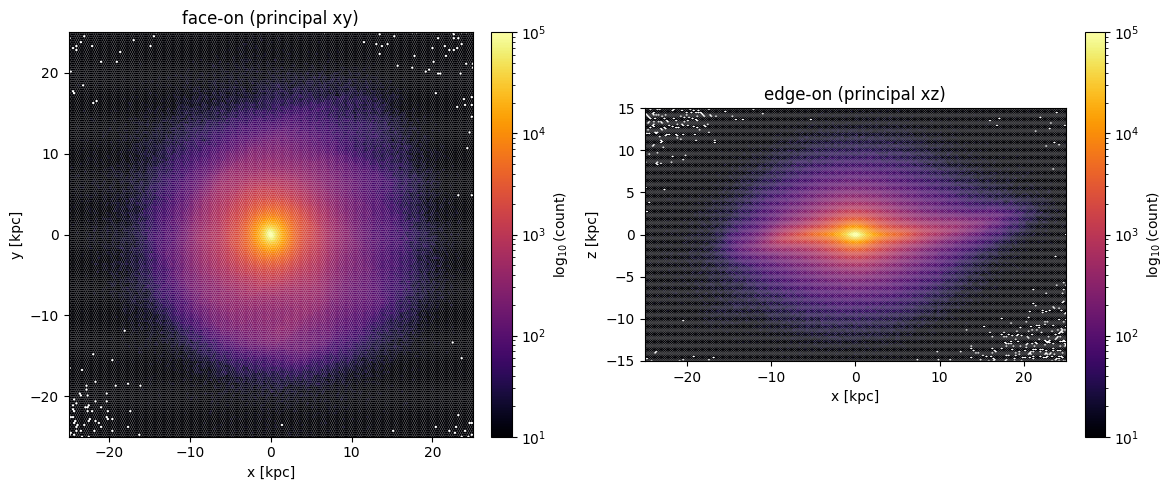

In [4]:
# Hexbin density maps (all stars — hexbin handles large N fine)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

hb0 = axes[0].hexbin(
    star_xyz[:, 0], star_xyz[:, 1],
    gridsize=180, bins='log', mincnt=1,
    extent=(-25, 25, -25, 25),
    cmap='inferno', linewidths=0,
    vmin=1e1,    # min log10(count) shown
    vmax=1e5,    # max log10(count) shown
)

axes[0].set_xlabel('x [kpc]')
axes[0].set_ylabel('y [kpc]')
axes[0].set_title('face-on (principal xy)')
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
cb0 = fig.colorbar(hb0, ax=axes[0], fraction=0.046, pad=0.04)
cb0.set_label(r'$\log_{10}$(count)')

hb1 = axes[1].hexbin(
    star_xyz[:, 0], star_xyz[:, 2],
    gridsize=(180, 110), bins='log', mincnt=1,
    extent=(-25, 25, -15, 15),
    cmap='inferno', linewidths=0,
    vmin=1e1,    # min log10(count) shown
    vmax=1e5,    # max log10(count) shown
)
axes[1].set_xlabel('x [kpc]')
axes[1].set_ylabel('z [kpc]')
axes[1].set_title('edge-on (principal xz)')
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-15, 15)
cb1 = fig.colorbar(hb1, ax=axes[1], fraction=0.046, pad=0.04)
cb1.set_label(r'$\log_{10}$(count)')

fig.tight_layout()

## 4. Define a Sun-like bubble

Place a mock Sun at `(x, y, z) = (R_sun, 0, 0)` in the principal frame
(so cylindrical `(R, φ, Z) = (8.2 kpc, 0, 0)`), and take a ball of radius 4 kpc around it.

This matches the geometry in `sun_los_recovery` (training ball around the Sun).

In [5]:
sun_xyz = np.array([R_SUN_KPC, 0.0, 0.0])  # principal-axis cartesian [kpc]

star_dist_to_sun = np.linalg.norm(star_xyz - sun_xyz, axis=1)
in_bubble = star_dist_to_sun < BUBBLE_RADIUS_KPC

print(f'stars in bubble: {in_bubble.sum():,} / {in_bubble.size:,}')
print(f'stellar mass in bubble: {star_mass[in_bubble].sum():.3e} Msun')

# Same cut for dark matter (needed later for gravity)
dark_dist_to_sun = np.linalg.norm(dark_xyz - sun_xyz, axis=1)
dark_in_bubble = dark_dist_to_sun < BUBBLE_RADIUS_KPC
print(f'dark particles in bubble: {dark_in_bubble.sum():,}')

stars in bubble: 299,910 / 13,976,485
stellar mass in bubble: 1.897e+09 Msun
dark particles in bubble: 71,083


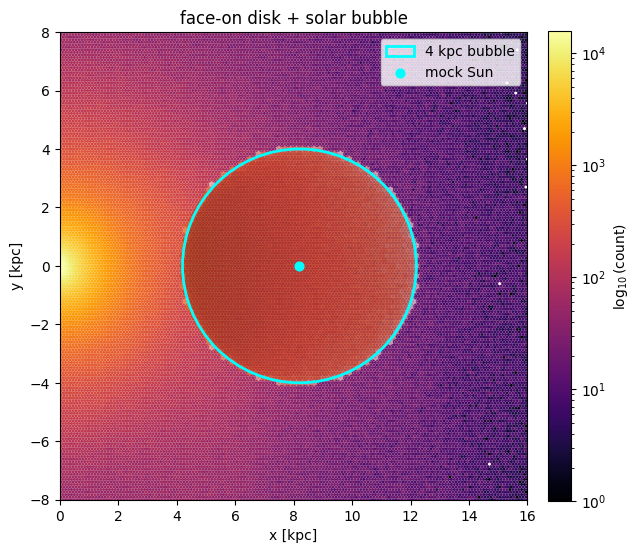

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 6))

# disk density
hb = ax.hexbin(
    star_xyz[:, 0], star_xyz[:, 1],
    gridsize=160, bins='log', mincnt=1,
    extent=(0, 16, -8, 8),
    cmap='inferno', linewidths=0,
)

# bubble stars as a second hexbin overlay
bubble_idx = np.flatnonzero(in_bubble)
ax.hexbin(
    star_xyz[bubble_idx, 0], star_xyz[bubble_idx, 1],
    gridsize=80, bins='log', mincnt=1,
    extent=(0, 16, -8, 8),
    cmap='Oranges', linewidths=0, alpha=0.55,
)

circ = plt.Circle(sun_xyz[:2], BUBBLE_RADIUS_KPC, fill=False, ec='cyan', lw=2, label='4 kpc bubble')
ax.add_patch(circ)
ax.scatter([sun_xyz[0]], [sun_xyz[1]], c='cyan', s=40, zorder=5, label='mock Sun')

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_title('face-on disk + solar bubble')
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, 16)
ax.set_ylim(-8, 8)
cb = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r'$\log_{10}$(count)')
ax.legend(loc='upper right')
fig.tight_layout()

## 5. Sample query positions inside the bubble

For now: **uniform in volume** inside the ball.
Later (for pulsar-like / PINN training): density-weighted sampling, since tracers live where mass is.

In [7]:
def sample_uniform_ball(center, radius, n, rng):
    """Uniform samples in a 3D ball."""
    # sample in ball via radius^(1/3) and random directions
    u = rng.normal(size=(n, 3))
    u /= np.linalg.norm(u, axis=1, keepdims=True)
    r = radius * rng.random(n) ** (1.0 / 3.0)
    return center + u * r[:, None]


N_QUERY = 200
query_xyz = sample_uniform_ball(sun_xyz, BUBBLE_RADIUS_KPC, N_QUERY, RNG)

# cylindrical for the queries too
query_cyl = ut.coordinate.get_positions_in_coordinate_system(
    query_xyz, 'cartesian', 'cylindrical'
)

print('query xyz shape:', query_xyz.shape)
print('query R range [kpc]:', query_cyl[:, 0].min(), '→', query_cyl[:, 0].max())
print('max |query - Sun| [kpc]:', np.linalg.norm(query_xyz - sun_xyz, axis=1).max())

query xyz shape: (200, 3)
query R range [kpc]: 4.296304795354059 → 12.051663977974794
max |query - Sun| [kpc]: 3.9937232268654768


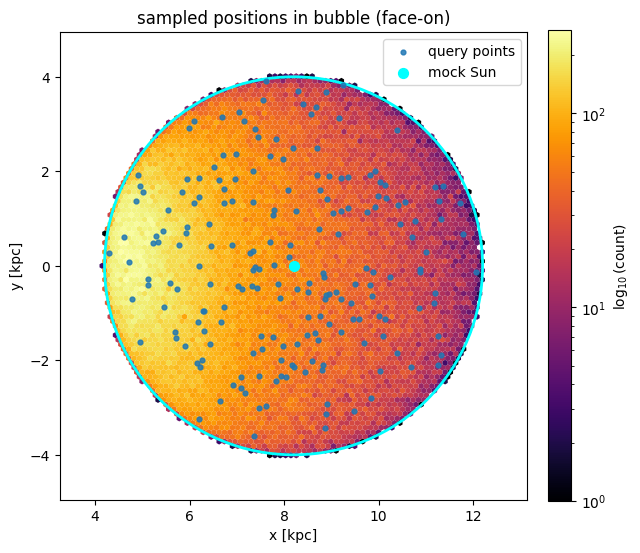

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 6))

hb = ax.hexbin(
    star_xyz[in_bubble, 0], star_xyz[in_bubble, 1],
    gridsize=80, bins='log', mincnt=1,
    extent=(R_SUN_KPC - BUBBLE_RADIUS_KPC - 0.5, R_SUN_KPC + BUBBLE_RADIUS_KPC + 0.5,
            -BUBBLE_RADIUS_KPC - 0.5, BUBBLE_RADIUS_KPC + 0.5),
    cmap='inferno', linewidths=0,
)
ax.scatter(query_xyz[:, 0], query_xyz[:, 1], s=12, c='C0', alpha=0.85, label='query points', zorder=3)
ax.scatter([sun_xyz[0]], [sun_xyz[1]], c='cyan', s=50, zorder=5, label='mock Sun')
circ = plt.Circle(sun_xyz[:2], BUBBLE_RADIUS_KPC, fill=False, ec='cyan', lw=2)
ax.add_patch(circ)

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_title('sampled positions in bubble (face-on)')
ax.set_aspect('equal', adjustable='box')
cb = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r'$\log_{10}$(count)')
ax.legend()
fig.tight_layout()

## 6. How do we get accelerations here?

The snapshot stores **gravitational potential** per particle (`potential`, units km²/s²),
but **not** acceleration. Options, from quick/dirty → better:

| approach | idea | pros | cons |
|---|---|---|---|
| A. Local ∇Φ from particles | fit Φ(x) ≈ Φ₀ + g·x near each query; a = −g | uses data you already loaded | noisy; softening scale; stars≠smooth field |
| B. Grid Φ + finite difference | bin particles → Φ grid → −∇Φ | simple | resolution / empty cells |
| C. Direct force sum | a ∝ Σ mᵢ (x−xᵢ)/|x−xᵢ|³ | "true" Newtonian | expensive; softening choices |
| D. **Basis expansion (EXP)** | you already have coef files under `data/fire/potential/` | smooth a everywhere; designed for this | need EXP/Agama-style reader |
| E. Δv between snapshots | a ≈ Δv/Δt | tempting | too coarse (~20 Myr); feedback noise; need 2 snaps |

**Recommendation for the project:** pursue **D** (EXP coefficients already downloaded) as the main path;
use **A** below as a sanity-check toy estimator while we learn the catalog.

Also note: particle `potential` is the full-box gravitational potential. Differentiating it
gives gravitational acceleration (good for pulsars), not hydro/feedback forces.

### 6a. Toy estimator: local least-squares ∇Φ

For each query point, take neighboring star+dark particles within `neigh_radius`,
fit `Φ ≈ c + g_x x + g_y y + g_z z`, and set `a = −g`.

Units: Φ is km²/s², positions in kpc, so `g` has units km²/s²/kpc.
Convert to km/s² by dividing by (km per kpc).

In [9]:
KPC_TO_KM = 3.0856775814913673e16  # km / kpc

# Combine star + dark near the bubble (slightly padded) for the local fit
pad = 1.0  # kpc beyond bubble for neighbors
star_near = star_dist_to_sun < (BUBBLE_RADIUS_KPC + pad)
dark_near = dark_dist_to_sun < (BUBBLE_RADIUS_KPC + pad)

neigh_xyz = np.vstack([star_xyz[star_near], dark_xyz[dark_near]])
neigh_phi = np.concatenate([
    part['star']['potential'][star_near],
    part['dark']['potential'][dark_near],
])
neigh_mass = np.concatenate([
    part['star']['mass'][star_near],
    part['dark']['mass'][dark_near],
])

print(f'neighbor catalog size: {neigh_xyz.shape[0]:,}')


def local_acceleration(query_points, neigh_xyz, neigh_phi, neigh_mass, neigh_radius=0.5, min_neighbors=30):
    """Estimate a = -∇Φ at query_points via local weighted linear fit of Φ.

    Returns accelerations in km/s^2, shape (N, 3). NaN where too few neighbors.
    """
    acc = np.full((query_points.shape[0], 3), np.nan, dtype=np.float64)

    for i, q in enumerate(query_points):
        d = np.linalg.norm(neigh_xyz - q, axis=1)
        sel = d < neigh_radius
        if sel.sum() < min_neighbors:
            continue

        X = neigh_xyz[sel] - q  # center design matrix at query
        y = neigh_phi[sel].astype(np.float64)
        w = neigh_mass[sel].astype(np.float64)
        # mild down-weight of distant neighbors inside the kernel
        w = w * np.clip(1.0 - d[sel] / neigh_radius, 0.05, None)

        # design: [1, x, y, z]
        A = np.column_stack([np.ones(X.shape[0]), X])
        Aw = A * w[:, None]
        try:
            coef, *_ = np.linalg.lstsq(Aw, y * w, rcond=None)
        except np.linalg.LinAlgError:
            continue

        # coef[1:] = ∇Φ in (km^2/s^2) / kpc  → a [km/s^2] = -∇Φ / (km per kpc)
        acc[i] = -coef[1:] / KPC_TO_KM

    return acc


acc_kms2 = local_acceleration(query_xyz, neigh_xyz, neigh_phi, neigh_mass, neigh_radius=0.75)
good = np.isfinite(acc_kms2).all(axis=1)
print(f'queries with valid a: {good.sum()} / {len(good)}')
print('median |a| [km/s^2]:', np.median(np.linalg.norm(acc_kms2[good], axis=1)))
print('median a components [km/s^2]:', np.median(acc_kms2[good], axis=0))

neighbor catalog size: 708,358
queries with valid a: 200 / 200
median |a| [km/s^2]: 2.1512210769769072e-13
median a components [km/s^2]: [-1.96510250e-13 -3.62368483e-15  1.39033487e-14]


order-of-magnitude |a| ~ v^2/R ≈ 1.913e-13 km/s^2


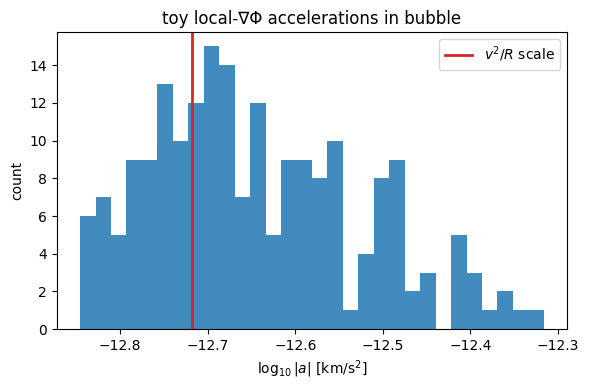

In [10]:
# Rough sanity check: at the Sun, Galactic |a| is ~order few × 10^-8 cm/s^2 ~ few × 10^-13 km/s^2
# (circular velocity ~220 km/s at 8 kpc → a ~ v^2/R).
v_circ_kms = 220.0
a_circ_expected = (v_circ_kms ** 2) / (R_SUN_KPC * KPC_TO_KM)  # km/s^2, centripetal scale
print(f'order-of-magnitude |a| ~ v^2/R ≈ {a_circ_expected:.3e} km/s^2')

fig, ax = plt.subplots(figsize=(6, 4))
a_mag = np.linalg.norm(acc_kms2[good], axis=1)
ax.hist(np.log10(a_mag), bins=30, color='C0', alpha=0.85)
ax.axvline(np.log10(a_circ_expected), color='C3', lw=2, label=r'$v^2/R$ scale')
ax.set_xlabel(r'$\log_{10}|a|$ [km/s$^2$]')
ax.set_ylabel('count')
ax.set_title('toy local-∇Φ accelerations in bubble')
ax.legend()
fig.tight_layout()

### 6b. What to do next

1. **Inspect EXP potentials** already on disk:
   - `data/fire/potential/EXP/` — HDF5 coefficient files (`MW_coef_*.h5`)
   - `data/fire/potential/10kpc/` — cylsp / multipole coefs + coord frames
   These are the right tool for smooth Φ and a at arbitrary points.
2. Convert accelerations into **galactoPINNs units** (kpc / Myr²) once we trust them.
3. Replace uniform bubble sampling with **density-weighted** sampling (star-mass weights).
4. Define LOS directions from the mock Sun and form pulsar-like observables `a · n̂`.

The toy ∇Φ estimator above is only a bridge — do **not** treat it as truth for the prior.

In [11]:
# Peek at available EXP / basis-function potential products
pot_exp = SIM_DIR / 'potential' / 'EXP'
pot_10 = SIM_DIR / 'potential' / '10kpc'

print('EXP coef files (sample):')
for p in sorted(pot_exp.glob('MW_coef_bs600*.h5'))[:6]:
    print(' ', p.name)

print('\n10kpc coef files (sample):')
for p in sorted(pot_10.glob('1.*'))[:8]:
    print(' ', p.name)

EXP coef files (sample):
  MW_coef_bs600_Mcut6_l20_n20_125kpc.h5
  MW_coef_bs600_Mcut6_l20_n20_350kpc.h5
  MW_coef_bs600_Mcut6_l20_n20_600kpc.h5
  MW_coef_bs600_Mcut6interpolated_l20_n20_125kpc.h5
  MW_coef_bs600_Mcut6interpolated_l20_n20_350kpc.h5
  MW_coef_bs600_Mcut6interpolated_l20_n20_600kpc.h5

10kpc coef files (sample):
  1.bar.axi_4.coef_cylsp_DR
  1.bar.none_4.coef_cylsp_DR
  1.dark.axi_4.coef_mul_DR
  1.dark.none_4.coef_mul_DR


tracers (age > 1 Gyr) in bubble: 265,349 of 299,910 bubble stars
median |z|: density draw 0.69 kpc, uniform ball 1.45 kpc  <- midplane concentration


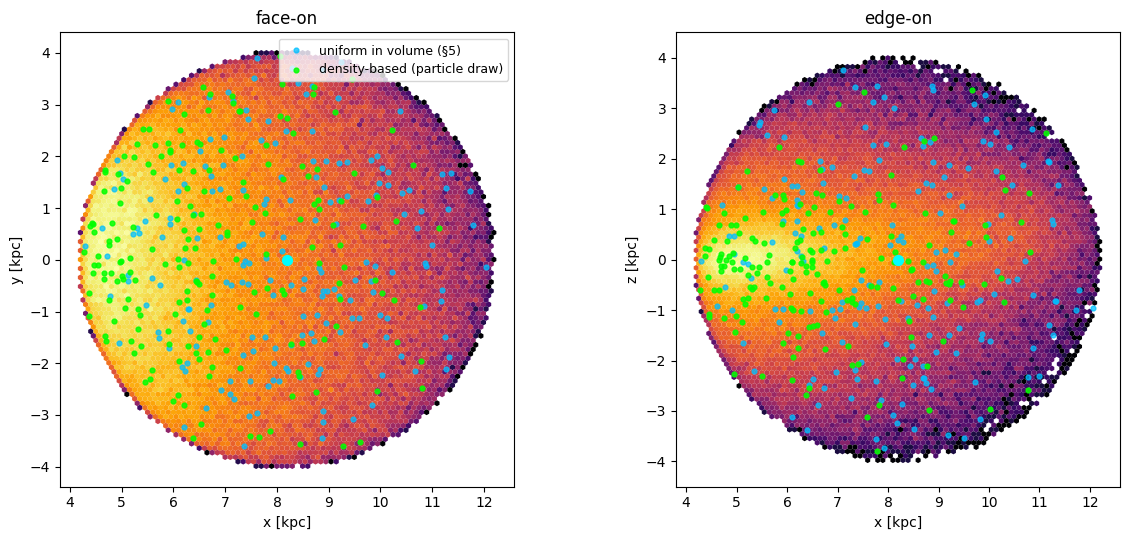

In [12]:
# ── 7. Density-based sampling (what fire_los_recovery actually does) ──────────
# How is the density estimated? It isn't — no KDE anywhere. FIRE star particles
# are near-equal-mass, so drawing PARTICLES uniformly at random IS drawing
# POSITIONS from the stellar mass density: the particle set is itself the
# Monte Carlo representation of ρ*(x). A KDE would only re-smooth it and add an
# arbitrary bandwidth. The experiment adds one physics cut before the draw:
# tracer age > 1 Gyr (the old, MSP-like population pulsars belong to).
try:
    star_age = part['star'].prop('age')  # [Gyr]; needs 'form.scalefactor' read
except Exception:
    # 'age' wasn't among this notebook's read properties — reuse the
    # experiment's prepared table (same snapshot, same reader, same order).
    star_age = np.load(
        Path('../../experiments/fire_los_recovery/cache/particles.npz'))['star_age']
    assert star_age.size == star_xyz.shape[0], 'particle-order mismatch'

tracer_in_bubble = in_bubble & (star_age > 1.0)
idx_dens = RNG.choice(np.flatnonzero(tracer_in_bubble), size=N_QUERY, replace=False)
query_dens_xyz = star_xyz[idx_dens]

print(f'tracers (age > 1 Gyr) in bubble: {tracer_in_bubble.sum():,} '
      f'of {in_bubble.sum():,} bubble stars')
print(f'median |z|: density draw {np.median(np.abs(query_dens_xyz[:, 2])):.2f} kpc, '
      f'uniform ball {np.median(np.abs(query_xyz[:, 2])):.2f} kpc  '
      f'<- midplane concentration')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.5))
for ax, j, ylab in [(axes[0], 1, 'y [kpc]'), (axes[1], 2, 'z [kpc]')]:
    ax.hexbin(star_xyz[in_bubble, 0], star_xyz[in_bubble, j],
              gridsize=80, bins='log', mincnt=1, cmap='inferno', linewidths=0)
    ax.scatter(query_xyz[:, 0], query_xyz[:, j], s=12, c='deepskyblue',
               alpha=0.75, label='uniform in volume (§5)')
    ax.scatter(query_dens_xyz[:, 0], query_dens_xyz[:, j], s=12, c='lime',
               alpha=0.85, label='density-based (particle draw)')
    ax.scatter([sun_xyz[0]], [sun_xyz[j]], c='cyan', s=50, zorder=5)
    ax.set_xlabel('x [kpc]')
    ax.set_ylabel(ylab)
    ax.set_aspect('equal', adjustable='box')
axes[0].set_title('face-on')
axes[1].set_title('edge-on')
axes[1].set_ylim(-4.5, 4.5)
axes[0].legend(loc='upper right', fontsize=9)
fig.tight_layout()

sim a_LOS at 30,000 tracers: median +2.54, 95% band [-5.21, +12.79] mm/s/yr
catalog: 51 pulsars (48 within 4 kpc of the Sun); 50/51 overlap the sim 95% band within ±1σ


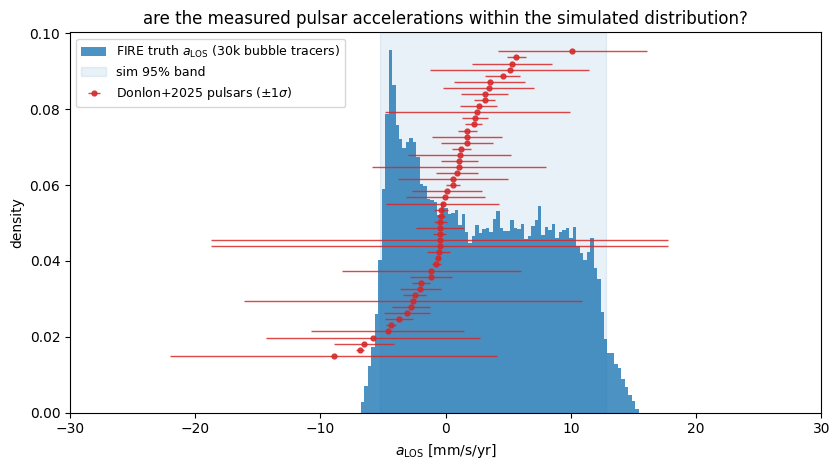

In [13]:
# ── 8. Truth a_LOS distribution (direct summation) + the real pulsar catalog ──
# Accelerations here are NOT the toy ∇Φ fit above: they come from the
# fire_los_recovery truth cache — pytreegrav octree summation over all ~147M
# particles (theta=0.5, quadrupoles, GIZMO spline softenings; validated against
# exact brute force, median 0.16%), host-frame relative. See
# experiments/fire_los_recovery/GUIDE_0_fire_truth.md for the physics decisions.
# Frame note: the experiment's Sun sits at (-8.1, 0, 0) kpc (house convention,
# shared by the catalog loader below), not this notebook's (+8.2, 0, 0) mock Sun.
import json
import sys

REPO = Path('../..').resolve()
zc = np.load(REPO / 'experiments/fire_los_recovery/cache/truth_old1gyr.npz',
             allow_pickle=True)
meta = json.loads(str(zc['meta']))
obs = np.asarray(meta['observer_kpc'])

KPCMYR2_TO_MMSYR = 977.79222  # 1 kpc/Myr^2 = 977.79 mm/s/yr
sep = zc['x_pool'] - obs                                   # Sun -> tracer sightlines
n_hat = sep / np.linalg.norm(sep, axis=1, keepdims=True)
a_los_sim = (zc['a_pool'] * n_hat).sum(axis=1) * KPCMYR2_TO_MMSYR

# Donlon+2025 measured pulsar a_LOS (orbital-decay PB where available, else
# spin-braking PS) — same observer/geometry conventions as the truth cache.
sys.path.insert(0, str(REPO / 'experiments/gp_audit'))
from catalog import load_catalog
cat = load_catalog()
al, sg = cat['alos_mmsyr'], cat['sigma_alos_mmsyr']

p_lo, p_hi = np.percentile(a_los_sim, [2.5, 97.5])
ok = (al - sg <= p_hi) & (al + sg >= p_lo)
print(f'sim a_LOS at {a_los_sim.size:,} tracers: median {np.median(a_los_sim):+.2f}, '
      f'95% band [{p_lo:+.2f}, {p_hi:+.2f}] mm/s/yr')
print(f'catalog: {cat["n_used"]} pulsars ({(cat["d_kpc"] < 4).sum()} within 4 kpc of the Sun); '
      f'{ok.sum()}/{cat["n_used"]} overlap the sim 95% band within ±1σ')

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.hist(a_los_sim, bins=80, density=True, color='C0', alpha=0.8,
        label=r'FIRE truth $a_{\rm LOS}$ (30k bubble tracers)')
ax.axvspan(p_lo, p_hi, color='C0', alpha=0.10, label='sim 95% band')
order = np.argsort(al)
y_pts = np.linspace(0.015, 0.95 * ax.get_ylim()[1], al.size)  # stagger for legibility
ax.errorbar(al[order], y_pts, xerr=sg[order], fmt='o', ms=3.5, lw=1,
            color='C3', alpha=0.85, label=r'Donlon+2025 pulsars ($\pm1\sigma$)')
ax.set_xlim(-30, 30)
ax.set_xlabel(r'$a_{\rm LOS}$ [mm/s/yr]')
ax.set_ylabel('density')
ax.set_title('are the measured pulsar accelerations within the simulated distribution?')
ax.legend(loc='upper left', fontsize=9)
fig.tight_layout()

# Caveat for the meeting: the catalog is noise-dominated (median σ ≈ 1.7
# mm/s/yr, the same order as the signal itself), so 'within distribution'
# checks consistency of scale and sign spread — not per-pulsar information.